# Step 4 — Predict one random test clip

Picks a random 16-frame sequence from the test split, runs it through the trained checkpoint from Step 2, and visualizes the predicted vs. true label over a 4×4 frame grid.

**Input:** `ds_driveguard_16frames_roi.nosync/test/{Safe,Drink,Phone}/{sequence_id}/frame_00.jpg ... frame_15.jpg`, `checkpoints/best_swin3d_driveguard.pt`

**Output:** predicted class + confidence, 4×4 frame visualization for the sampled sequence

## Setup — imports, device, dataset-root resolution

In [11]:
import random
from pathlib import Path
from typing import Dict, List, Tuple

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from PIL import Image
from torchvision import transforms
from torchvision.models.video import swin3d_t


DEFAULT_CLASSES = ["Safe", "Drink", "Phone"]
DEFAULT_CHECKPOINT = str(Path.cwd() / "checkpoints" / "best_swin3d_driveguard.pt")


In [12]:
def get_device() -> torch.device:
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


def _is_valid_dataset_root(path: Path) -> bool:
    return path.exists() and (path / "train").exists() and (path / "val").exists() and (path / "test").exists()


def resolve_data_root(data_root_arg: str) -> Path:
    raw = Path(data_root_arg).expanduser()
    workspace_root = Path.cwd().resolve().parent.parent.parent  # .../gmar

    candidates = [
        raw,
        Path.cwd() / raw,
        workspace_root / raw,
        workspace_root / "matala" / raw.name,
    ]

    seen = set()
    for candidate in candidates:
        resolved = candidate.resolve()
        if resolved in seen:
            continue
        seen.add(resolved)
        if _is_valid_dataset_root(resolved):
            return resolved

    raise RuntimeError(
        "No valid dataset root found. Expected a folder containing train/val/test. "
        f"Tried argument '{data_root_arg}' and common locations around the project."
    )


## Model loading + sequence helpers

In [13]:
def get_model(num_classes: int, dropout: float = 0.3) -> nn.Module:
    model = swin3d_t(weights=None)
    in_features = model.head.in_features
    model.head = nn.Sequential(
        nn.Dropout(p=dropout),
        nn.Linear(in_features, num_classes),
    )
    return model


def load_checkpoint(ckpt_path: Path, device: torch.device) -> Tuple[nn.Module, List[str]]:
    checkpoint = torch.load(ckpt_path, map_location=device)

    class_to_idx: Dict[str, int] = checkpoint.get("class_to_idx", {name: i for i, name in enumerate(DEFAULT_CLASSES)})
    idx_to_class = [""] * len(class_to_idx)
    for class_name, idx in class_to_idx.items():
        idx_to_class[idx] = class_name

    training_args = checkpoint.get("args", {})
    dropout = float(training_args.get("dropout", 0.3))
    model = get_model(num_classes=len(idx_to_class), dropout=dropout)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.to(device)
    model.eval()
    return model, idx_to_class


def list_test_sequences(data_root: Path) -> List[Tuple[Path, str]]:
    test_root = data_root / "test"
    sequences: List[Tuple[Path, str]] = []
    for class_name in DEFAULT_CLASSES:
        class_dir = test_root / class_name
        if not class_dir.exists():
            continue
        for seq_dir in class_dir.iterdir():
            if not seq_dir.is_dir():
                continue
            frames = sorted(seq_dir.glob("frame_*.jpg"))
            if len(frames) == 16:
                sequences.append((seq_dir, class_name))
    return sequences


def load_sequence_tensor(frame_paths: List[Path], image_size: int) -> torch.Tensor:
    transform = transforms.Compose(
        [
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ]
    )
    frames = []
    for frame_path in frame_paths:
        image = Image.open(frame_path).convert("RGB")
        frames.append(transform(image))
    return torch.stack(frames, dim=1)  # (C, T, H, W)


def plot_frames(frame_paths: List[Path], true_label: str, pred_label: str, seq_dir: Path) -> None:
    fig, axes = plt.subplots(4, 4, figsize=(12, 12))
    for idx, frame_path in enumerate(frame_paths):
        r, c = divmod(idx, 4)
        image = Image.open(frame_path).convert("RGB")
        axes[r, c].imshow(image)
        axes[r, c].set_title(f"Frame {idx:02d}", fontsize=9)
        axes[r, c].axis("off")

    fig.suptitle(
        f"Sequence: {seq_dir.name}\nTrue: {true_label} | Predicted: {pred_label}",
        fontsize=14,
        fontweight="bold",
    )
    fig.tight_layout()
    plt.show()


## Config — edit these, then run

In [14]:
cfg = {
    "data_root": "ds_driveguard_16frames_roi.nosync",
    "checkpoint": DEFAULT_CHECKPOINT,
    "image_size": 224,
    "seed": None,  # set an int for deterministic sampling
}


## Run prediction

[INFO] Using device: mps
[INFO] Dataset root: /Users/baryosef/Desktop/gmar/matala/ds_driveguard_16frames_roi.nosync
[INFO] Picked sequence: /Users/baryosef/Desktop/gmar/matala/ds_driveguard_16frames_roi.nosync/test/Drink/a_column_co_driver_vp5_run1_2018-05-22-15-10-41.ids_2_ann34_ch1
[RESULT] True label: Drink
[RESULT] Predicted: Drink (confidence=0.9566)


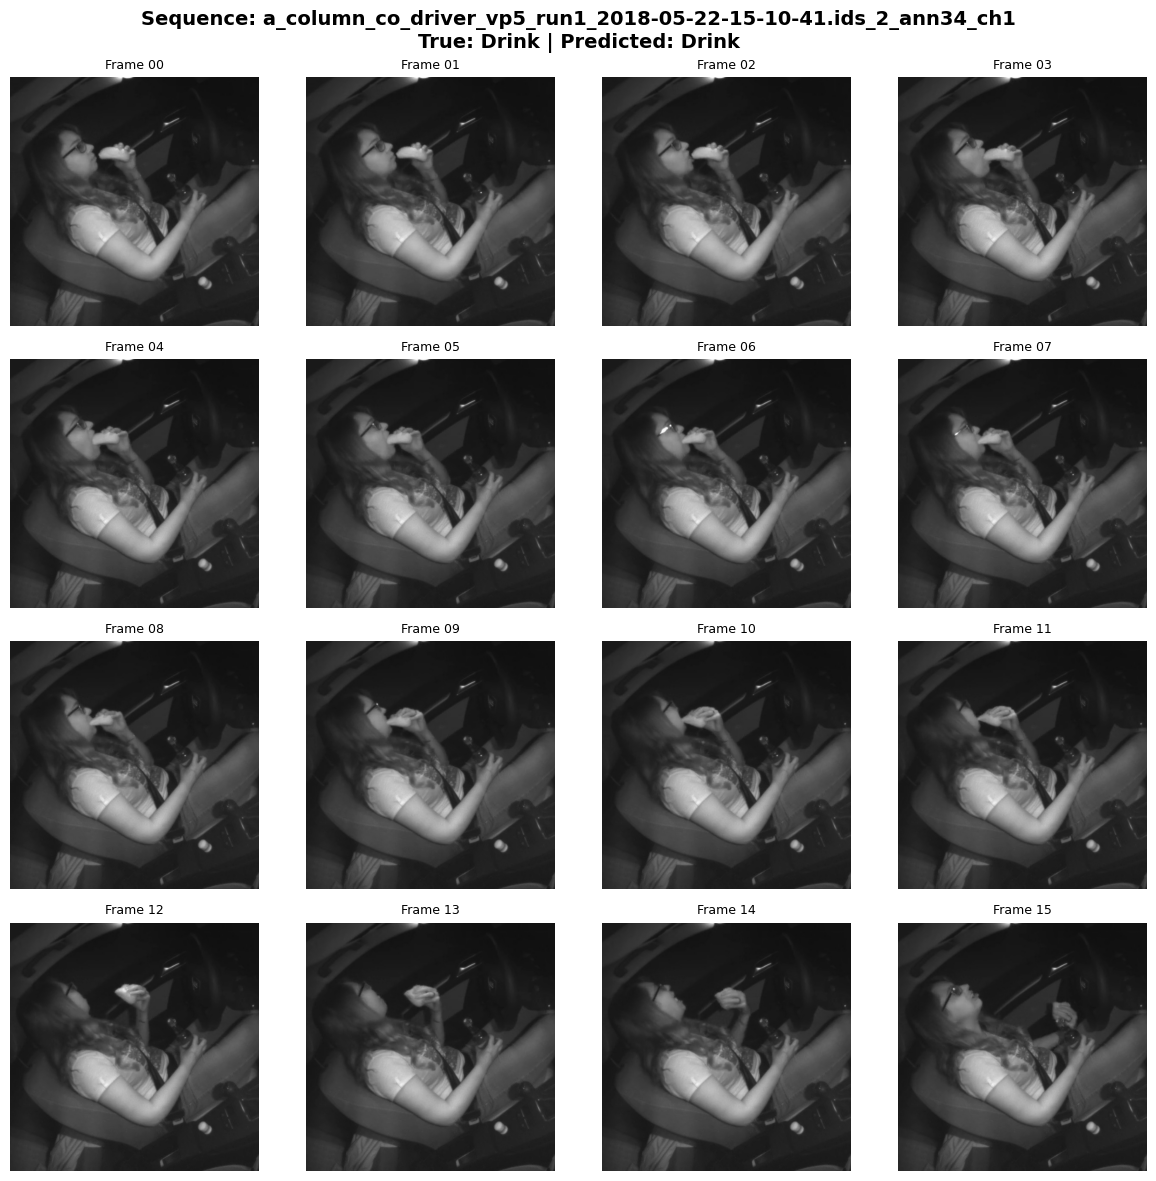

In [15]:
if cfg["seed"] is not None:
    random.seed(cfg["seed"])

data_root = resolve_data_root(cfg["data_root"])
ckpt_path = Path(cfg["checkpoint"])
device = get_device()
print(f"[INFO] Using device: {device}")
print(f"[INFO] Dataset root: {data_root}")

if not ckpt_path.exists():
    raise FileNotFoundError(f"Checkpoint not found: {ckpt_path}")
if not (data_root / "test").exists():
    raise FileNotFoundError(f"Test folder not found: {data_root / 'test'}")

sequences = list_test_sequences(data_root)
if not sequences:
    raise RuntimeError("No valid 16-frame sequences found in test split.")

seq_dir, true_label = random.choice(sequences)
frame_paths = sorted(seq_dir.glob("frame_*.jpg"))
print(f"[INFO] Picked sequence: {seq_dir}")

model, idx_to_class = load_checkpoint(ckpt_path, device)
video = load_sequence_tensor(frame_paths, image_size=cfg["image_size"]).unsqueeze(0).to(device)  # (1, C, T, H, W)

with torch.no_grad():
    logits = model(video)
    probs = torch.softmax(logits, dim=1)[0]
    pred_idx = int(torch.argmax(probs).item())

pred_label = idx_to_class[pred_idx]
confidence = float(probs[pred_idx].item())

print(f"[RESULT] True label: {true_label}")
print(f"[RESULT] Predicted: {pred_label} (confidence={confidence:.4f})")
plot_frames(frame_paths, true_label=true_label, pred_label=pred_label, seq_dir=seq_dir)
